In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import yfinance as yf

# Define the stock symbol and the period for which you want to retrieve data
stock_symbol = 'AAPL'  # Example: Apple Inc.
start_date = '2010-01-01'
end_date = '2024-08-04'

# Fetch historical data with a 1-day interval
stock_data = yf.download(stock_symbol, start=start_date, end=end_date, interval='1d')



[*********************100%%**********************]  1 of 1 completed


In [4]:
stock_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.461977,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.473149,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.370185,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.358407,477131200
2010-01-08,7.510714,7.571429,7.466429,7.570714,6.400681,447610800


[*********************100%%**********************]  1 of 1 completed


Initial Capital: $100000.00
Final Portfolio Value: $100014.49
Total Market Return: 2.55
Total Strategy Return: 1.10


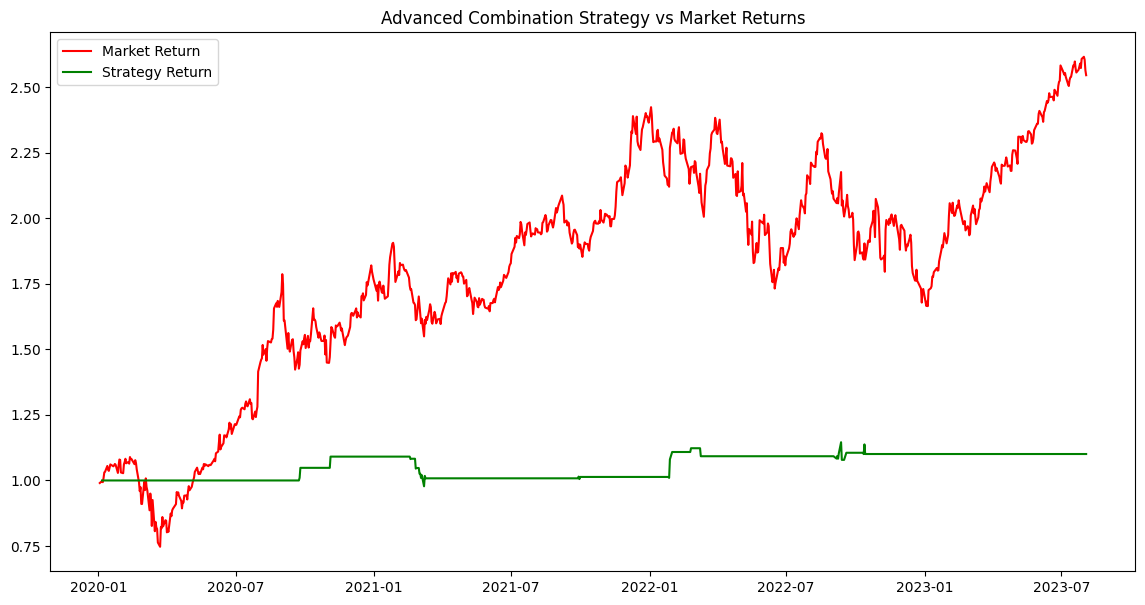

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np

# Fetch historical stock data
stock_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-08-04'
stock_data = yf.download(stock_symbol, start=start_date, end=end_date, interval='1d')

# Calculate moving averages
short_window = 40
long_window = 100
stock_data['Short_MA'] = stock_data['Close'].rolling(window=short_window, min_periods=1).mean()
stock_data['Long_MA'] = stock_data['Close'].rolling(window=long_window, min_periods=1).mean()

# Calculate RSI (Relative Strength Index)
window_length = 14
delta = stock_data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=window_length).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=window_length).mean()
rs = gain / loss
stock_data['RSI'] = 100 - (100 / (1 + rs))

# Calculate Bollinger Bands
bb_window = 20
stock_data['Middle_Band'] = stock_data['Close'].rolling(window=bb_window).mean()
stock_data['Upper_Band'] = stock_data['Middle_Band'] + 2*stock_data['Close'].rolling(window=bb_window).std()
stock_data['Lower_Band'] = stock_data['Middle_Band'] - 2*stock_data['Close'].rolling(window=bb_window).std()

# Generate Buy/Sell signals based on combined strategy
stock_data['Buy_Signal'] = np.where(
    (stock_data['Short_MA'] > stock_data['Long_MA']) & 
    (stock_data['RSI'] < 30) & 
    (stock_data['Close'] > stock_data['Lower_Band']),
    1, 0)

stock_data['Sell_Signal'] = np.where(
    (stock_data['Short_MA'] < stock_data['Long_MA']) & 
    (stock_data['RSI'] > 70) & 
    (stock_data['Close'] < stock_data['Upper_Band']),
    1, 0)

# Generate position based on signals
stock_data['Position'] = 0  # Default to no position
stock_data['Position'] = np.where(stock_data['Buy_Signal'] == 1, 1, stock_data['Position'])
stock_data['Position'] = np.where(stock_data['Sell_Signal'] == 1, 0, stock_data['Position'])
stock_data['Position'] = stock_data['Position'].ffill().shift(1)  # Forward fill and shift for next day's open

# Backtesting the strategy
initial_capital = 100000.0
stock_data['Portfolio Value'] = initial_capital + (stock_data['Close'].diff() * stock_data['Position'].shift(1)).cumsum()

# Calculate returns
stock_data['Daily Return'] = stock_data['Close'].pct_change()
stock_data['Strategy Return'] = stock_data['Daily Return'] * stock_data['Position'].shift(1)

# Calculate cumulative returns
stock_data['Cumulative Market Return'] = (1 + stock_data['Daily Return']).cumprod()
stock_data['Cumulative Strategy Return'] = (1 + stock_data['Strategy Return']).cumprod()

# Print strategy performance
final_value = stock_data['Portfolio Value'].iloc[-1]
market_return = stock_data['Cumulative Market Return'].iloc[-1]
strategy_return = stock_data['Cumulative Strategy Return'].iloc[-1]

print(f"Initial Capital: ${initial_capital:.2f}")
print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Total Market Return: {market_return:.2f}")
print(f"Total Strategy Return: {strategy_return:.2f}")

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(stock_data['Cumulative Market Return'], label='Market Return', color='r')
plt.plot(stock_data['Cumulative Strategy Return'], label='Strategy Return', color='g')
plt.title('Advanced Combination Strategy vs Market Returns')
plt.legend()
plt.show()


[*********************100%%**********************]  1 of 1 completed


Initial Capital: $100000.00
Final Portfolio Value: $100000.00
Total Market Return: 2.55
Total Strategy Return: 1.00


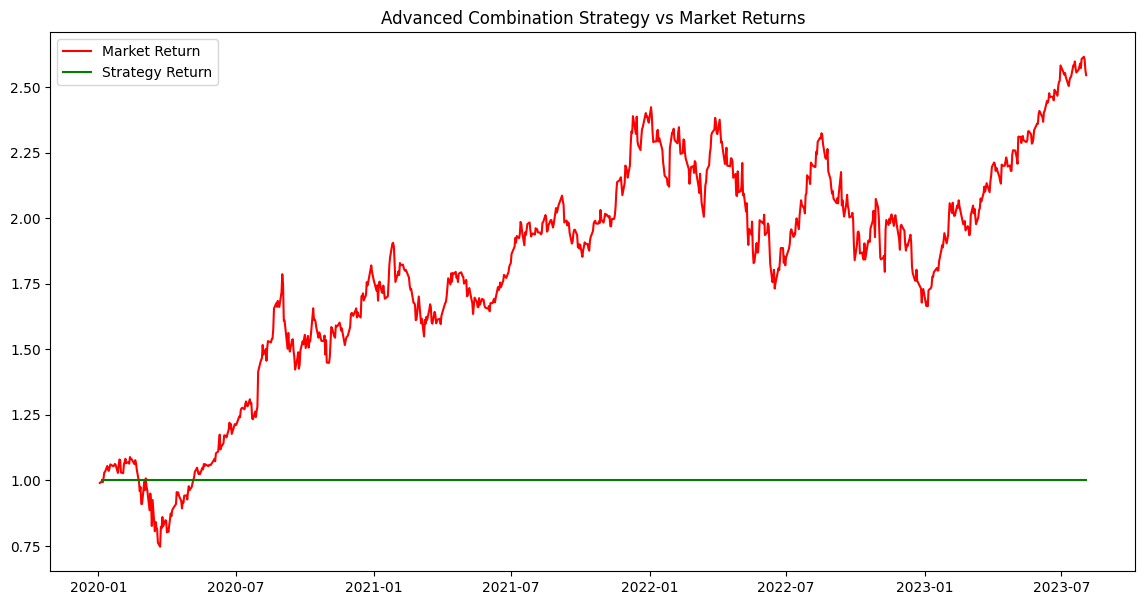

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def fetch_data(symbol, start_date, end_date, interval):
    # Fetch historical stock data
    return yf.download(symbol, start=start_date, end=end_date, interval=interval)

def calculate_indicators(data):
    # Calculate EMAs
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

    # Calculate RSI
    window_length = 14
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window_length).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window_length).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))

    # Calculate MACD
    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = ema_12 - ema_26
    data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

    # Calculate ATR (Average True Range)
    high_low = data['High'] - data['Low']
    high_close = np.abs(data['High'] - data['Close'].shift())
    low_close = np.abs(data['Low'] - data['Close'].shift())
    tr = high_low.combine(high_close, max).combine(low_close, max)
    data['ATR'] = tr.rolling(window=14).mean()

    return data

def generate_signals(data):
    # Signal generation
    data['Buy_Signal'] = np.where(
        (data['EMA_20'] > data['EMA_50']) &
        (data['RSI'] < 30) &
        (data['MACD'] > data['Signal_Line']) &
        (data['ATR'] < data['ATR'].mean()), 1, 0)

    data['Sell_Signal'] = np.where(
        (data['EMA_20'] < data['EMA_50']) &
        (data['RSI'] > 70) &
        (data['MACD'] < data['Signal_Line']) &
        (data['ATR'] < data['ATR'].mean()), 1, 0)

    # Generate position based on signals
    data['Position'] = 0  # Default to no position
    data['Position'] = np.where(data['Buy_Signal'] == 1, 1, data['Position'])
    data['Position'] = np.where(data['Sell_Signal'] == 1, 0, data['Position'])
    data['Position'] = data['Position'].ffill().shift(1)  # Forward fill and shift for next day's open

    return data

def backtest_strategy(data, initial_capital):
    # Backtesting the strategy
    data['Portfolio Value'] = initial_capital + (data['Close'].diff() * data['Position'].shift(1)).cumsum()

    # Calculate returns
    data['Daily Return'] = data['Close'].pct_change()
    data['Strategy Return'] = data['Daily Return'] * data['Position'].shift(1)

    # Calculate cumulative returns
    data['Cumulative Market Return'] = (1 + data['Daily Return']).cumprod()
    data['Cumulative Strategy Return'] = (1 + data['Strategy Return']).cumprod()

    # Performance evaluation
    final_value = data['Portfolio Value'].iloc[-1]
    market_return = data['Cumulative Market Return'].iloc[-1]
    strategy_return = data['Cumulative Strategy Return'].iloc[-1]

    print(f"Initial Capital: ${initial_capital:.2f}")
    print(f"Final Portfolio Value: ${final_value:.2f}")
    print(f"Total Market Return: {market_return:.2f}")
    print(f"Total Strategy Return: {strategy_return:.2f}")

    return data

def plot_results(data):
    plt.figure(figsize=(14, 7))
    plt.plot(data['Cumulative Market Return'], label='Market Return', color='r')
    plt.plot(data['Cumulative Strategy Return'], label='Strategy Return', color='g')
    plt.title('Advanced Combination Strategy vs Market Returns')
    plt.legend()
    plt.show()

# Parameters
stock_symbol = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-08-04'
interval = '1d'  # You can change this to '1h', '1wk', '1mo', etc.
initial_capital = 100000.0

# Run the strategy
data = fetch_data(stock_symbol, start_date, end_date, interval)
data = calculate_indicators(data)
data = generate_signals(data)
data = backtest_strategy(data, initial_capital)
plot_results(data)
